In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look better
plt.style.use('ggplot')

In [7]:
df = pd.read_csv('netflix_titles.csv')

# Basic inspection
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year added
df['year_added'] = df['date_added'].dt.year

# Drop irrelevant columns
df = df.drop(['description'], axis=1)

In [9]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [10]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


In [11]:
df['year_added'].value_counts().sort_index()

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418


In [12]:
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [13]:
df.groupby(['year_added', 'type']).size().unstack()

type,Movie,TV Show
year_added,,
2008.0,1.0,1.0
2009.0,2.0,NaN
2010.0,1.0,NaN
2011.0,13.0,NaN
2012.0,3.0,NaN
2013.0,6.0,4.0
2014.0,19.0,4.0
2015.0,56.0,17.0
2016.0,253.0,165.0


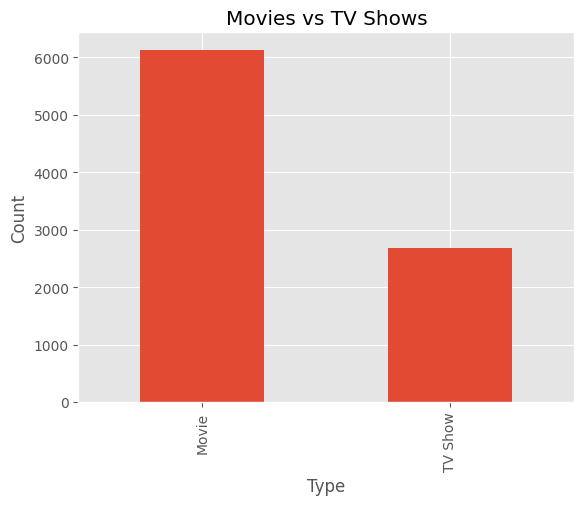

In [14]:
df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

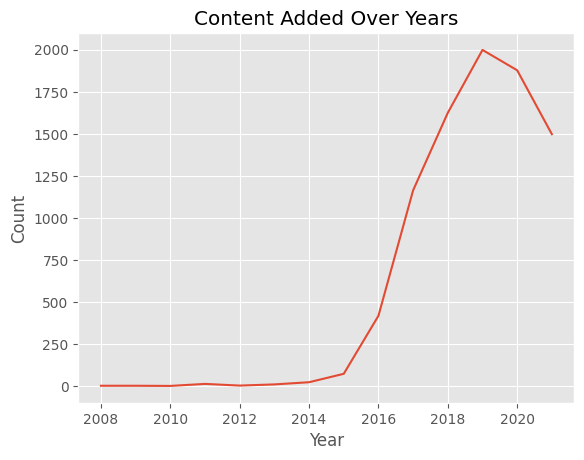

In [15]:
df['year_added'].value_counts().sort_index().plot()
plt.title('Content Added Over Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

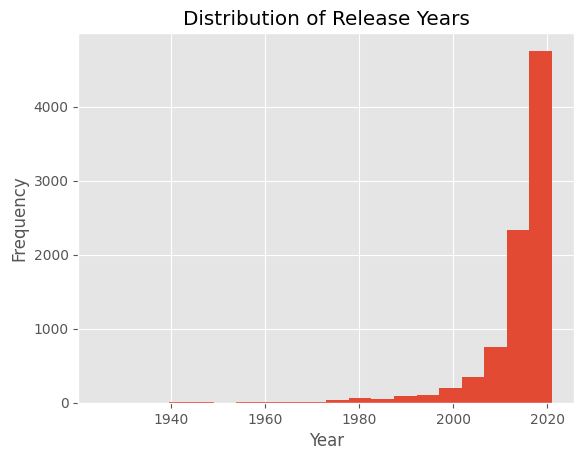

In [16]:
df['release_year'].plot(kind='hist', bins=20)
plt.title('Distribution of Release Years')
plt.xlabel('Year')
plt.show()

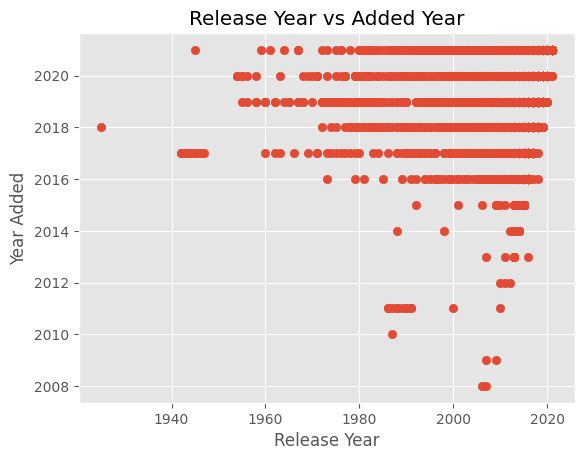

In [17]:
plt.scatter(df['release_year'], df['year_added'])
plt.title('Release Year vs Added Year')
plt.xlabel('Release Year')
plt.ylabel('Year Added')
plt.show()

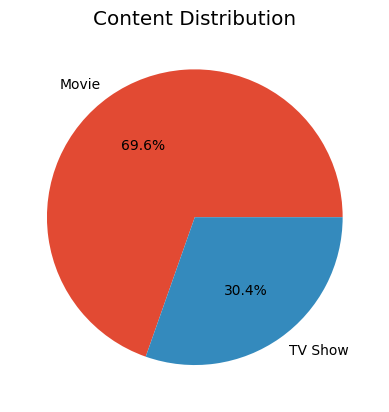

In [18]:
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Content Distribution')
plt.ylabel('')
plt.show()

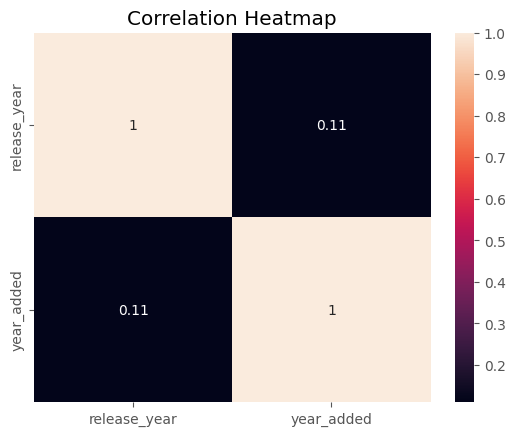

In [19]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

# Netflix Data Analysis Project
## AI & ML Internship Project

This project analyzes Netflix movies and TV shows dataset to find patterns, trends, and insights.

## Data Summary

The dataset contains information about Netflix movies and TV shows.
It includes features like title, director, cast, country, and release year.
The dataset contains both categorical and numerical data.
Some columns have missing values such as director and country.
This dataset helps analyze trends in Netflix content.

## Data Cleaning

Duplicate rows were removed to ensure data accuracy.
Missing values were filled using placeholders like 'Unknown'.
The date_added column was converted into datetime format.
A new column 'year_added' was created for analysis.
Irrelevant columns like description were removed.

## Exploratory Data Analysis

The following questions are analyzed:
1. Movies vs TV Shows distribution
2. Top content-producing countries
3. Content growth over years
4. Most common ratings
5. Trend of content types over time

## Data Visualizations

The following charts are created:
- Bar Chart
- Line Chart
- Histogram
- Scatter Plot
- Pie Chart
- Heatmap

## Insights

1. Movies dominate Netflix content compared to TV Shows.
2. Content increased rapidly after 2015.
3. Most content is produced in a few countries like the US and India.
4. TV-MA and TV-14 are the most common ratings.
5. Older content is added frequently in recent years.

## Surprising Finding

The most surprising insight was the rapid growth in content after 2015, showing Netflix’s aggressive expansion.